# GPSR + LUME-Cheetah example — the fit

**Goal of the example.** Reconstruct a beam's 6D phase space from measured screen
images, by tracking a *trainable* beam through a **differentiable, frozen** model of
the beamline until the simulated images match the measurements.

| Step | |
|---|---|
| 1 | Assemble a `GPSRLUMEModel`: the frozen accelerator + a trainable beam generator |
| 2 | Load the measurements `GPSRLUMEDataModule` |
| 3 | Fit a fresh, untrained beam to them, and compare predicted against measured images |
| 4 | Checkpoint, and rebuild the whole model from the checkpoint alone |

Only the beam generator is trainable. The accelerator is frozen: it is the *model of
the measurement*, not something being fit.

## Why a builder path, and not a saved model

Notebook 1 built a `LUMECheetahModel` by hand and saved nothing. This notebook
rebuilds it from the same files through
`example_virtual_accelerator.factory.build_accelerator`, reached by its **dotted
import path**. That indirection is the whole reason a checkpoint here is
self-contained: it records *how to rebuild* its accelerator — including the current,
possibly calibrated, lattice — as plain JSON, so it loads with `weights_only=True`.

In [1]:
from pathlib import Path

import lightning as L
import torch
from gpsr.beams import NNParticleBeamGenerator
from gpsr.losses import kl_div_loss

from gpsr.lume.builders import serialize_gpsr_lume_model
from gpsr.lume.data import GPSRLUMEDataModule
from gpsr.lume.model import GPSRLUMEModel
from gpsr.lume.plotting import plot_beam_distribution, plot_multi_source_images
from gpsr.lume.predicting import predict_multi_source_images
from gpsr.lume.training import LitGPSRLUME

# the example's own package, found via the notebook's own directory -- which is
# why the dotted builder path a checkpoint records resolves on reload.
from example_virtual_accelerator.factory import BUILDER_IMPORT_PATH, build_accelerator

# The fit starts from a randomly initialized generator, so seed it: without this the
# reconstruction below differs run to run, and a demonstration that cannot be
# reproduced is hard to learn from. Given a seed the fit is deterministic -- verified
# bit-for-bit over a repeated run.
SEED = 0
L.seed_everything(SEED, workers=True)

Seed set to 0


0

## `GPSRLUMEModel` and `LitGPSRLUME`

`GPSRLUMEModel` consists of a `BeamGenerator` at the reconstruction point and a
`LUMECheetahModel` virtual accelerator of the diagnostics lattice. `LitGPSRLUME` is the
PyTorch Lightning training object.

In [2]:
DESIGN_ENERGY = 125.0e6  # eV -- reference momentum p0c, shared by beam and accelerator
LATTICE_PATH = "example_virtual_accelerator/lattice_6d.json"

# Training hyperparameters.
LEARNING_RATE = 1e-3
MAX_EPOCHS = 100
N_PARTICLES = 10_000
OUTPUT_SCALE = 2e-3

# The frozen half: exactly what notebook 1 built, through the builder a checkpoint
# records by import path.
accelerator = build_accelerator(lattice=LATTICE_PATH, energy=DESIGN_ENERGY)

# The trainable half: a neural network mapping a fixed base distribution to particle
# coordinates. These weights are the only thing the fit changes.
beam_generator = NNParticleBeamGenerator(
    n_particles=N_PARTICLES,
    energy=DESIGN_ENERGY,
    n_dim=6,
    output_scale=OUTPUT_SCALE,
)

# create the GPSRLUMEModel, which combines the frozen accelerator and trainable beam generator
gpsr_lume_model = GPSRLUMEModel(
    lume_cheetah_model=accelerator,
    beam_generator=beam_generator,
    accelerator_spec={
        "builder": BUILDER_IMPORT_PATH,
        "config": {"lattice": LATTICE_PATH},
    },
)

# create the LightningModule that wraps the GPSRLUMEModel and adds training logic.
# The loss is a training argument with no library default -- the harness has no
# opinion on what you fit with, and a model built only to predict needs none.
lit_model = LitGPSRLUME(gpsr_lume_model, lr=LEARNING_RATE, loss_func=kl_div_loss)

print("PV interface of the frozen accelerator:")
for pv_name in sorted(accelerator.supported_variables):
    print("   ", pv_name)
print(
    "\ntrainable parameters:",
    sum(p.numel() for p in lit_model.parameters() if p.requires_grad),
)

PV interface of the frozen accelerator:
    Q1:BCTRL
    Q2:BCTRL
    Q3:BCTRL
    Q4:BCTRL
    S1:Image:ArrayData
    S2:Image:ArrayData
    TDC:AREQ
    TDC:PREQ

trainable parameters: 1106


In [3]:
# Because the provenance was recorded, the model can describe itself: this is the
# canonical **spec**, one JSON-pure dict naming two addressed constructors. Note the
# lattice comes back as JSON *text* read from the live segment, not the path given
# above -- that is how calibration applied after the build gets captured.
spec = serialize_gpsr_lume_model(gpsr_lume_model)

print("accelerator builder:", spec["accelerator"]["builder"])
print(
    "accelerator config :",
    {
        k: f"<{len(v)} chars of lattice JSON>"
        for k, v in spec["accelerator"]["config"].items()
    },
)
print("generator cls      :", spec["generator"]["cls"])
print("generator config   :", spec["generator"]["config"])

# So the whole cell above collapses to this, once a spec exists -- the path used when
# reloading a checkpoint, and the one to prefer in scripts:
equivalent_model = LitGPSRLUME.from_spec(spec, lr=LEARNING_RATE, loss_func=kl_div_loss)
print(
    "\nfrom_spec gives the same PV interface:",
    sorted(equivalent_model.gpsr_lume_model.lume_cheetah_model.supported_variables)
    == sorted(accelerator.supported_variables),
)

accelerator builder: example_virtual_accelerator.factory.build_accelerator
accelerator config : {'lattice': '<3104 chars of lattice JSON>'}
generator cls      : gpsr.beams.NNParticleBeamGenerator
generator config   : {'n_particles': 10000, 'energy': 125000000.0, 'output_scale': 0.002, 'n_dim': 6}

from_spec gives the same PV interface: True


## `GPSRLUMEDataModule`

This is the training data to fit the beam distribution of the `GPSRLUMEModel`. Consists
of various `GPSRLUMEDataset`, each corresponding to quad scan data.

In [4]:
DATASETS_DIR = Path("datasets")  # written by data_module.ipynb -- run that first

# load training data GPSRLUMEDataModule
datamodule = GPSRLUMEDataModule.load(DATASETS_DIR / "gpsr_lume_datamodule.pt")

# inspect the GPSRLUMEDataModule
datamodule

GPSRLUMEDataModule(
  batch_size=full, num_workers=0, pin_memory=False
  sources: ['S1_tdc_off', 'S1_tdc_on', 'S2_tdc_off', 'S2_tdc_on']
  datasets:
    [S1_tdc_off] GPSRLUMEDataset(n_samples=7)
        Data: TensorDict(
          fields={
              beamline_settings: TensorDict(
                  fields={
                      Q2:BCTRL: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
                      TDC:AREQ: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False),
              observations: TensorDict(
                  fields={
                      S1:Image:ArrayData: Tensor(shape=torch.Size([7, 200, 400]), device=cpu, dtype=torch.float32, is_shared=False)},
                  batch_size=torch.Size([7]),
                  device=None,
                  is_shared=False)},
          batch_size=torch.Size([

## Training

In [5]:
# Re-seeded here so the fit does not depend on how much randomness the cells above
# happened to consume: `train_dataloader` shuffles each epoch, which changes the order
# images are summed in, and over `MAX_EPOCHS` of an unstable objective that is enough
# to move the answer. Pinning it here makes this cell reproducible on its own.
L.seed_everything(SEED, workers=True)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="cpu",
    devices=1,
    logger=False,  # a real run wants a TensorBoardLogger here
    enable_checkpointing=False,  # next section shows checkpointing explicitly
    log_every_n_steps=1,
)
trainer.fit(lit_model, datamodule=datamodule)

Seed set to 0


/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tt ...
GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gpsr_lume_model │ GPSRLUMEModel │  1.1 K │ train │     0 │
└───┴─────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 57                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=100` reached.


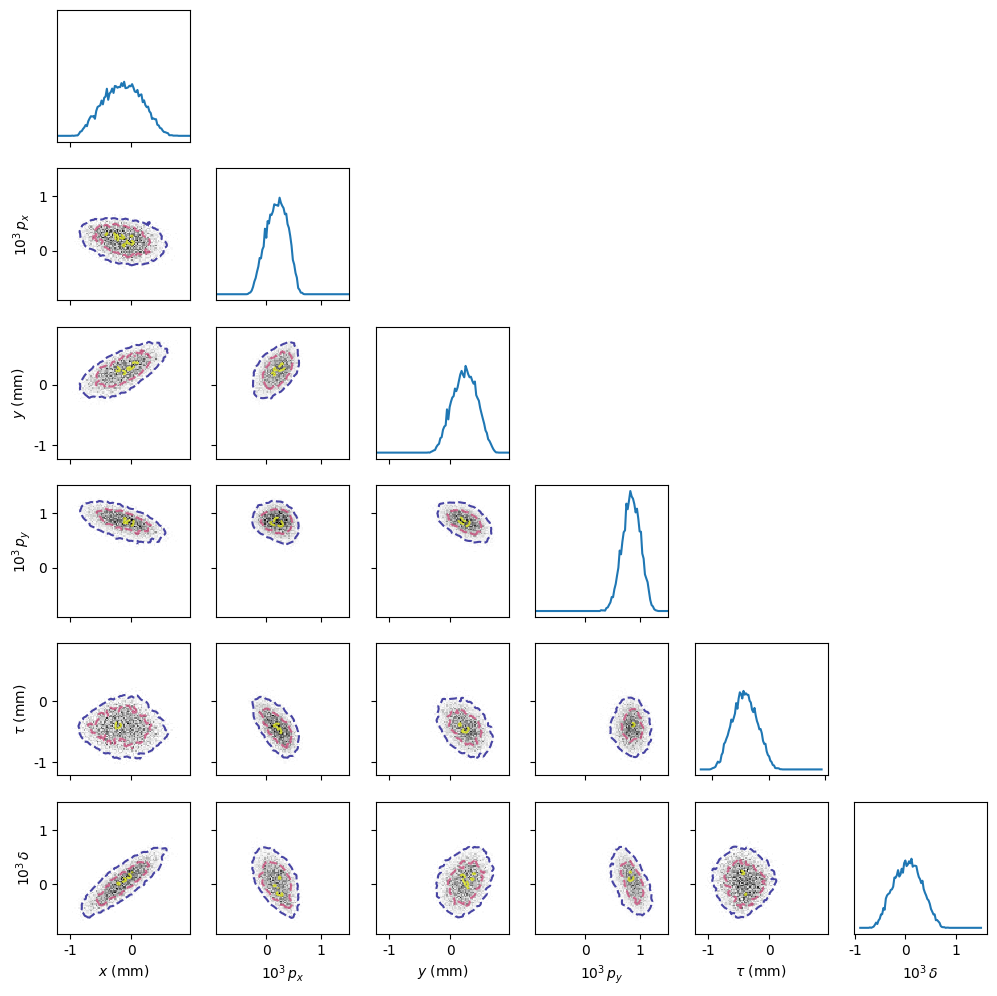

In [6]:
# the reconstruction is the trained generator's beam
reconstructed_beam = lit_model.gpsr_lume_model.beam_generator()
fig, axes = plot_beam_distribution(reconstructed_beam, bin_ranges="unit_same")

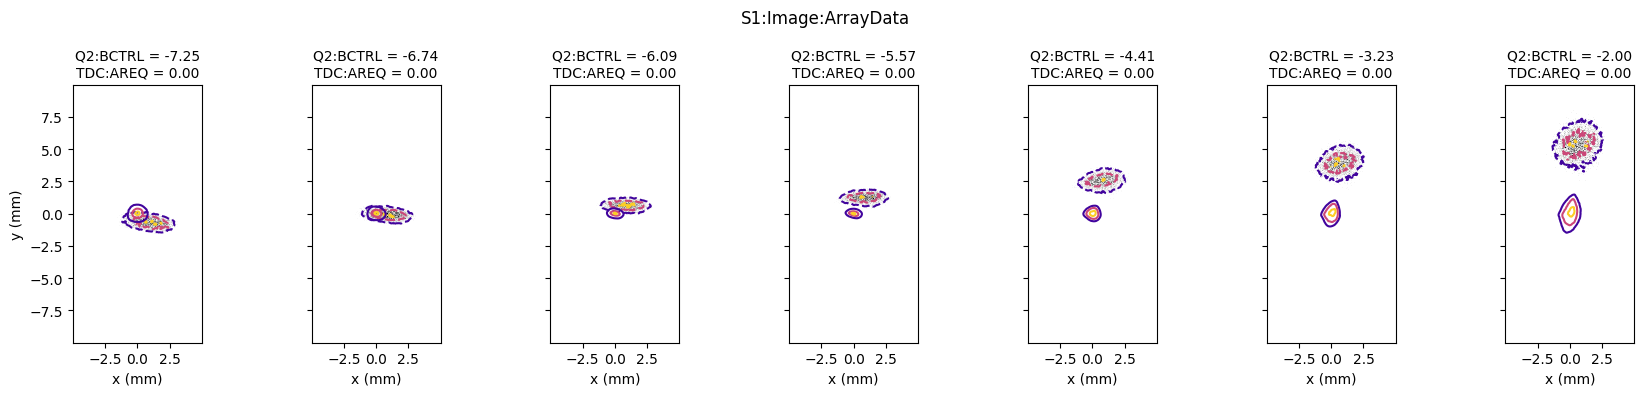

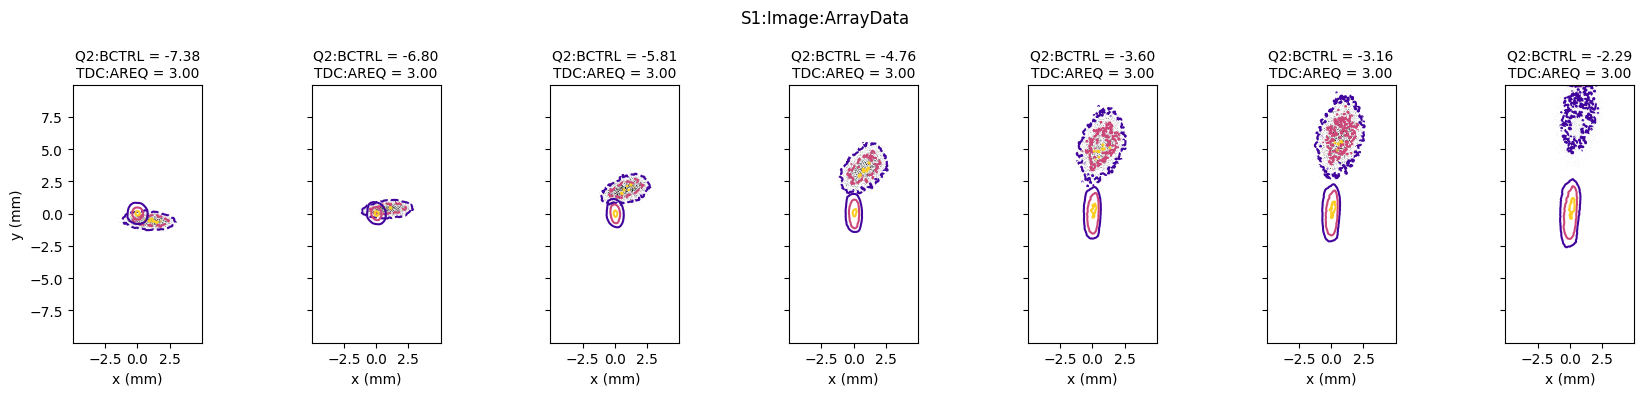

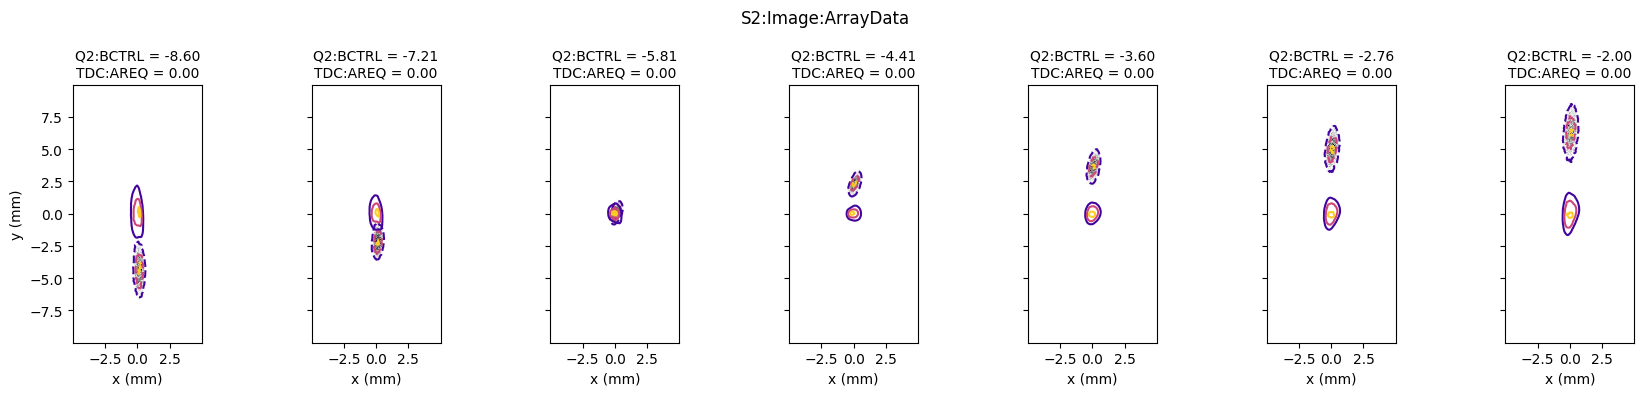

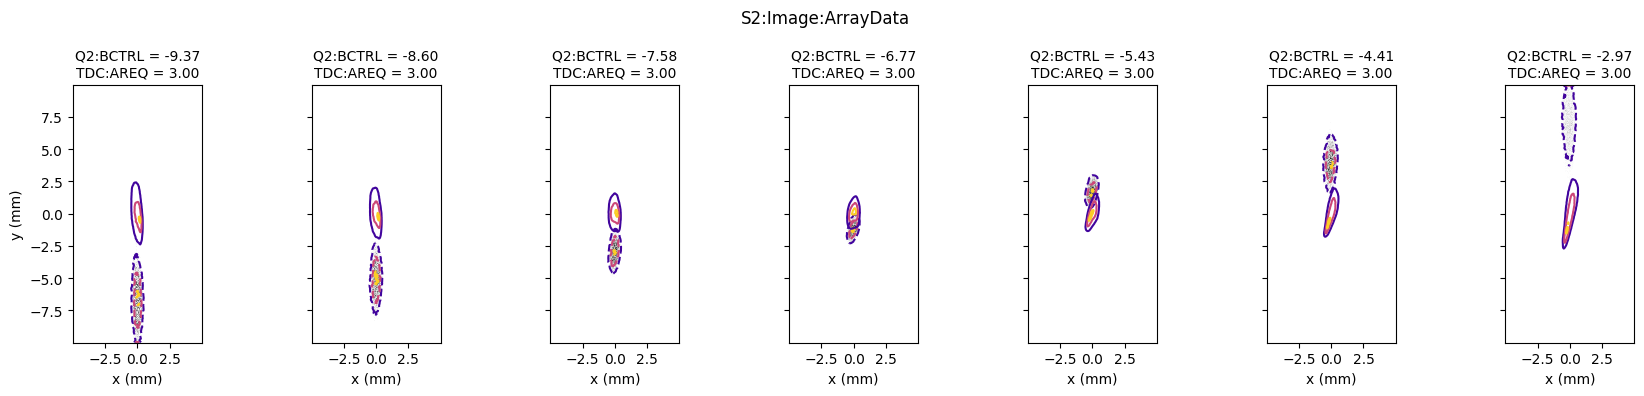

In [7]:
# Predicted images vs the measurements they were fit to. Dashed contours are the
# first argument (predictions), solid are the overlay (measurements).
predicted_images = predict_multi_source_images(
    model=lit_model, sources_spec=datamodule.to_sources_spec()
)
figures = plot_multi_source_images(
    images=predicted_images,
    sources_spec=datamodule.to_sources_spec(),
    overlay_images=datamodule.to_observations(),
    contours=True,
)

## Checkpoint, and rebuild from it alone

`on_save_checkpoint` does two things: it strips the frozen accelerator's state (large
transient beam buffers — only the trained generator weights are worth keeping), and it
embeds the **spec** built above. The spec's lattice is re-read from the *live*
segment, so an accelerator adjusted after the build is captured as adjusted. What the
last training batch left on the *scanned* magnets is deliberately not captured; the
second cell below shows what survives and what is dropped.

Everything stored is a string, number, or plain dict, which is what lets the
checkpoint load with `weights_only=True` — no pickled classes, no facility import.

In [8]:
CHECKPOINT_PATH = "example_reconstruction.ckpt"

# Lightning logs "`weights_only` was not set, defaulting to `False`" here. That is
# *its* flag, deciding whether to also dump optimizer and callback state, and has
# nothing to do with the `weights_only=` of `torch.load` below.
trainer.save_checkpoint(CHECKPOINT_PATH)

# The point of JSON purity: this succeeds.
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=True)
embedded_spec = checkpoint["gpsr_lume_spec"]

print(
    "builder unchanged  :",
    embedded_spec["accelerator"]["builder"] == spec["accelerator"]["builder"],
)
print("generator unchanged:", embedded_spec["generator"] == spec["generator"])
print(
    "\nstate_dict keys (frozen accelerator stripped):", sorted(checkpoint["state_dict"])
)

`weights_only` was not set, defaulting to `False`.


builder unchanged  : True
generator unchanged: True

state_dict keys (frozen accelerator stripped): ['gpsr_lume_model.beam_generator.base_particles', 'gpsr_lume_model.beam_generator.beam_energy', 'gpsr_lume_model.beam_generator.particle_charges', 'gpsr_lume_model.beam_generator.survival_probabilities', 'gpsr_lume_model.beam_generator.transformer.output_scale', 'gpsr_lume_model.beam_generator.transformer.stack.0.bias', 'gpsr_lume_model.beam_generator.transformer.stack.0.weight', 'gpsr_lume_model.beam_generator.transformer.stack.2.bias', 'gpsr_lume_model.beam_generator.transformer.stack.2.weight', 'gpsr_lume_model.beam_generator.transformer.stack.5.bias', 'gpsr_lume_model.beam_generator.transformer.stack.5.weight', 'gpsr_lume_model.beam_generator.transformer.stack.8.bias', 'gpsr_lume_model.beam_generator.transformer.stack.8.weight']


In [9]:
# The embedded lattice, however, is *not* the one serialized before the fit, and the
# differences are the point: it is re-read from the live segment, so it records the
# accelerator as the fit actually saw it. `build_accelerator` takes lattice JSON text
# as readily as a path, so both can be loaded back and compared element by element.
before = build_accelerator(
    lattice=spec["accelerator"]["config"]["lattice"], energy=DESIGN_ENERGY
).simulator.segment
after = build_accelerator(
    lattice=embedded_spec["accelerator"]["config"]["lattice"], energy=DESIGN_ENERGY
).simulator.segment

print(
    "lattice JSON:",
    len(spec["accelerator"]["config"]["lattice"]),
    "chars before the fit ->",
    len(embedded_spec["accelerator"]["config"]["lattice"]),
    "after\n",
)

for element_before, element_after in zip(before.elements, after.elements):
    for feature in element_after.defining_tensors:
        old, new = getattr(element_before, feature), getattr(element_after, feature)
        if old.shape != new.shape or not torch.equal(old, new):
            print(
                f"    {element_after.name}.{feature}: {old.tolist()} -> {new.tolist()}"
            )

lattice JSON: 3104 chars before the fit -> 3102 after

    tdc.voltage: 0.0 -> 3000000.0
    s1.kde_bandwidth: 4.999999873689376e-05 -> 2.499999936844688e-05
    q3.k1: 11.344200134277344 -> 11.344199180603027
    s2.kde_bandwidth: 4.999999873689376e-05 -> 2.499999936844688e-05


In [10]:
# Two kinds of difference, both records of the machine:
#
#   * `q_.k1` -- a constant quadrupole differing in its last float digit, from the
#     round trip through its action variable's control units. Real, and worth having:
#     it is the strength the fit was actually solved against.
#   * `tdc.voltage` -- the TDC was held at one value across each source's scan, so
#     that single value is exactly the accelerator's setting and is kept.
#
# What is *absent* is a third kind: the scanned `q2.k1`, which the last batch left
# as a 7-element tensor, one entry per scan step. A batch of scan settings is
# transient state rather than a property of the beamline, so
# `serialize_gpsr_lume_model` collapses it back to the recorded value. Otherwise the
# checkpoint's lattice would be a mid-scan snapshot -- and the rebuilt segment would
# carry a stale 7-wide scan axis until something happened to overwrite it.
scanned = after.q2.k1
print(f"q2.k1 in the record: shape {tuple(scanned.shape)}, value {scanned.tolist()}")
print(
    "live segment at save time:",
    tuple(lit_model.gpsr_lume_model.lume_cheetah_model.simulator.segment.q2.k1.shape),
)

q2.k1 in the record: shape (), value -10.913399696350098
live segment at save time: (7,)


In [11]:
# Rebuild the accelerator from the embedded spec and restore the trained weights.
# Nothing but the checkpoint file is needed -- no lattice path, no measurements, no
# model. The facility package must be *importable*, because the builder is named by
# its dotted path; it does not need to be imported here.
reloaded_model = LitGPSRLUME.load_self_contained(CHECKPOINT_PATH, map_location="cpu")

reloaded_predictions = predict_multi_source_images(
    model=reloaded_model,
    sources_spec=datamodule.to_sources_spec(),
    beam=reconstructed_beam,
)
identical = all(
    torch.allclose(predicted_images[source][pv], reloaded_predictions[source][pv])
    for source in predicted_images
    for pv in predicted_images[source]
)
print("reloaded model reproduces the predictions exactly:", identical)

reloaded model reproduces the predictions exactly: True


/sdf/group/ad/beamphysics/jpga/miniforge3/envs/ml-tto-dev/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.0.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.voltage', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.phase', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.frequency', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.misalignment', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.1.tilt', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.2.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.3.length', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elements.3.k1', 'gpsr_lume_model.lume_cheetah_model.simulator.segment.elemen